In [1]:
setwd("~/data_path/P7_LUAD2")

In [47]:
library(Seurat)
library(ggpubr)
library(ggplot2)
library(patchwork)
library(fastCNV)
library(dplyr)
library(tidyr)
library(rstatix)

## Step1

### Create a Seurat object and export the expression data.

In [4]:
data.dir = "~/data_path/P7_LUAD2/filtered_feature_bc_matrix"
data = Read10X(data.dir = data.dir)
object <- CreateSeuratObject(counts = data$`Gene Expression`, assay = "Spatial", min.cells = 3,  min.features = 10)
object

10X data contains more than one type and is being returned as a list containing matrices of each type.



In [7]:
image <- Read10X_Image(
    image.dir = "~/data_path/rawdata/P7_LUAD2/spatial",
    image.name = "tissue_lowres_image.png",
    filter.matrix = TRUE
)

In [8]:
img <- "P7_LUAD2"
image <- image[Cells(x = object)]
DefaultAssay(object = image) <- "Spatial"
object[[img]] <- image 

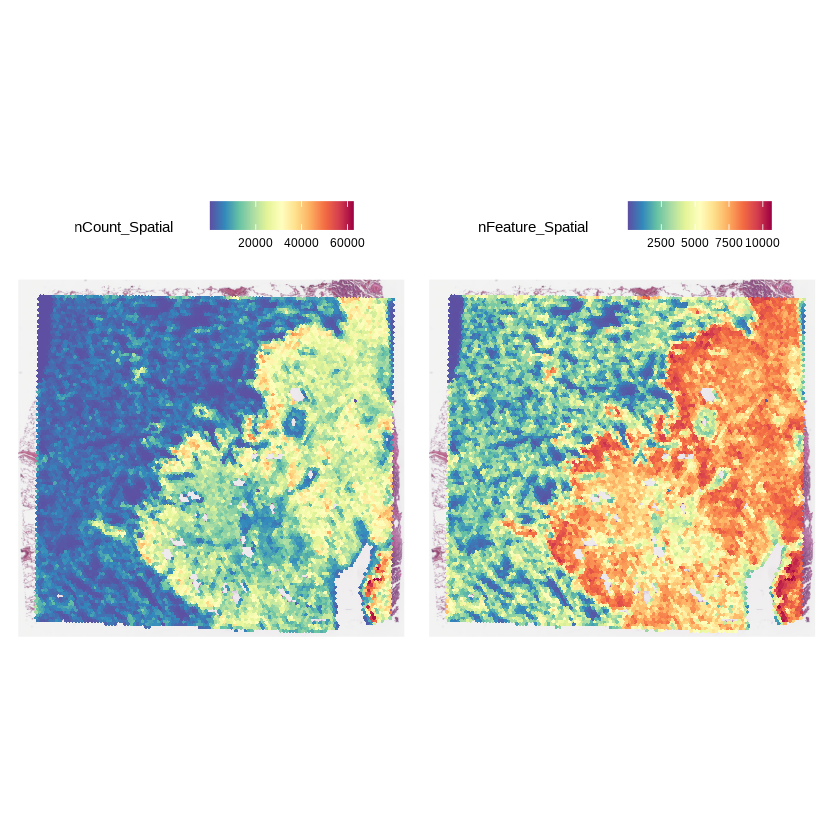

In [9]:
p <- SpatialFeaturePlot(object, features =c('nCount_Spatial','nFeature_Spatial'),pt.size.factor = 2) 
p

In [10]:
object <- NormalizeData(object, normalization.method = "LogNormalize", scale.factor = 10000)
object <- FindVariableFeatures(object, selection.method = "vst", nfeatures = 2000)
object <- ScaleData(object)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



In [11]:
expr <- GetAssayData(object, assay = "Spatial", layer = "data")

In [12]:
gene = read.csv("~/data_path/ccle_tpm_select.csv",header = T, row.names = 1)
genes_to_keep <- rownames(gene)
genes_to_keep <- intersect(rownames(expr), genes_to_keep)
expr <- expr[genes_to_keep, ]
dim(expr)
write.csv(as.matrix(expr), file = "./P7_LUAD2_spot_expression.csv")

[1]  3193 13074

Saving 6.67 x 6.67 in image


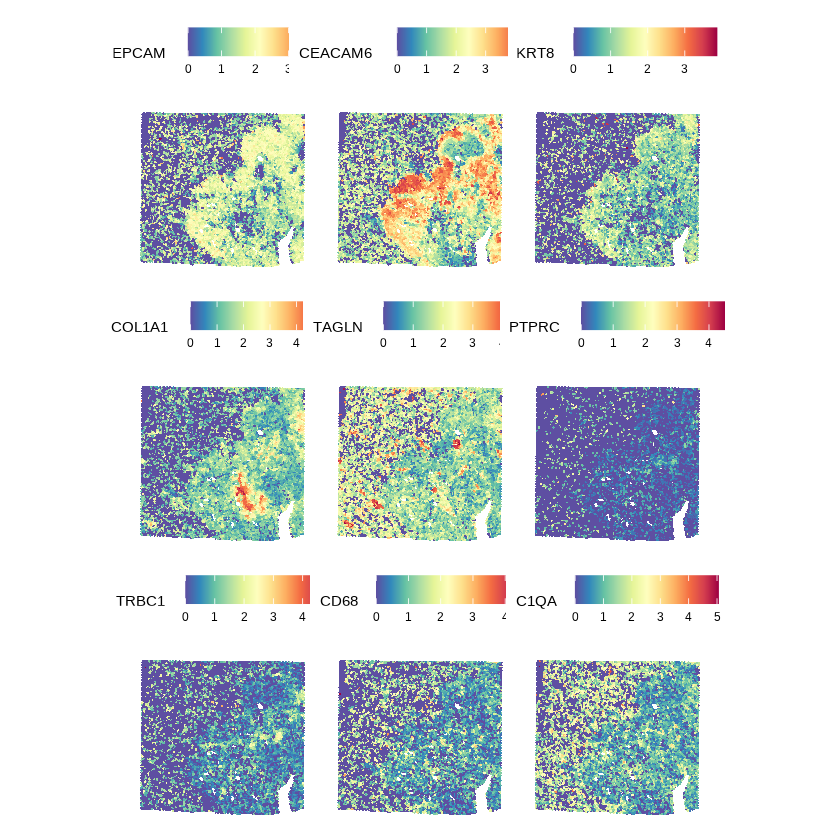

In [7]:
p = SpatialFeaturePlot(object,
                       features = c('EPCAM','CEACAM6','KRT8','COL1A1','TAGLN','PTPRC','TRBC1','CD68','C1QA'),
                       pt.size.factor = 2.2,
                       image.alpha = 0
                      )
p
ggsave(p, file = "P7-2_marker.pdf")

## Step2

### Inference spatial clones using FastCNV.

In [ ]:
object <- RunPCA(object)
object <- FindNeighbors(object, dims = 1:30)
object <- FindClusters(object, resolution = seq(0.1, 1, by = 0.1), algorithm = 4)
object <- RunUMAP(object, dims = 1:30)

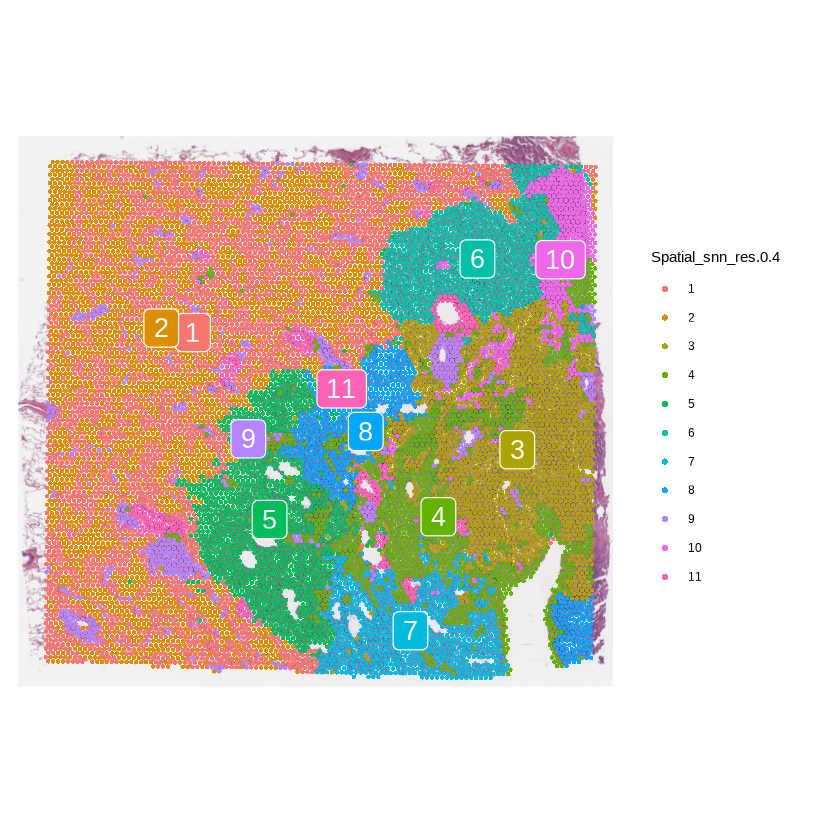

In [25]:
SpatialDimPlot(object,group.by = "Spatial_snn_res.0.4", label = TRUE)

In [27]:
genes_to_check = c(
  'PTPRC',
  'PECAM1','CDH5','VWF','KDR','ESAM','CLDN5','PLVAP',
  'CD19','MS4A1','CD79A','CD79B','CD22','BANK1',
  'CD3D','CD3E','CD3G','CD4','CD8A','CD8B','TRAC','TRBC1',
  'NKG7','GNLY','GZMA','GZMB','KLRD1','KLRC1',
  'CD14','FCGR3A','S100A8','S100A9','LYZ',
  'AIF1','C1QA','C1QB','CD68','CD163','MRC1','CD80','CD86',
  'CPA3','MS4A2','TPSAB1',
  'COL1A1','DCN','LUM','PDGFRA','PDGFRB','ACTA2','TAGLN',
  'EPCAM','KRT18','KRT19','KRT8','KRT7','KRT20',
  'MKI67','STMN1','PCNA','TOP2A'
)

Warning message:
“The following requested variables were not found: CD8B, TPSAB1, KRT18”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


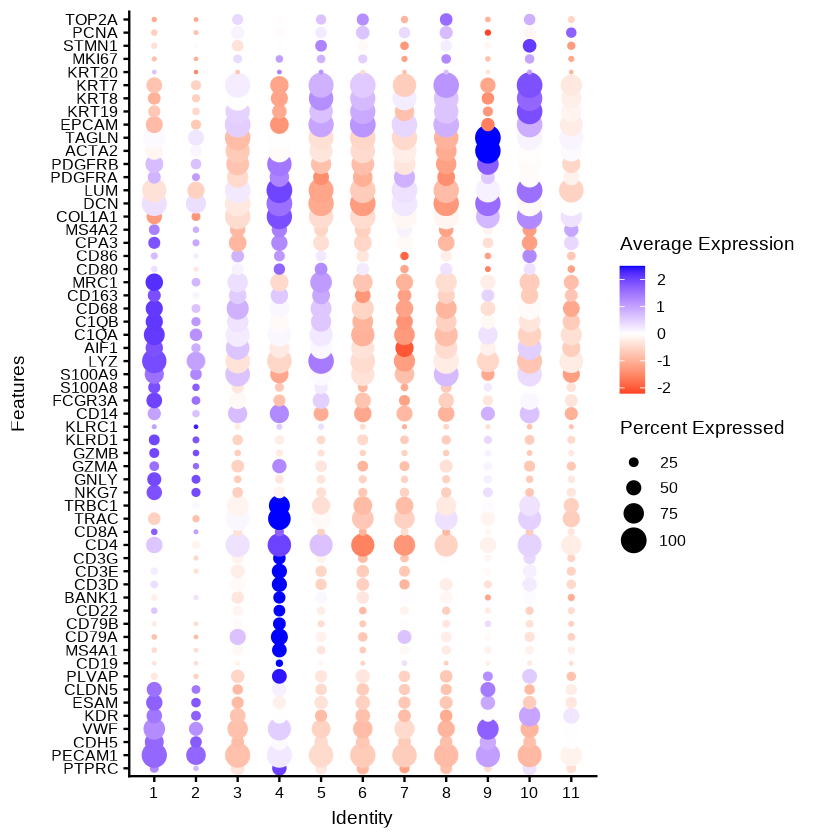

In [28]:
p = DotPlot(object, features = unique(genes_to_check),group.by = 'Spatial_snn_res.0.4',
            assay='Spatial'  )  + coord_flip() +   scale_color_gradient2(low = "red", mid = "white", high = "blue", 
                                                                      midpoint = 0)  
p

In [ ]:
# Run FastCNV using the "1" cluster as the reference.

[2026-03-25 18:57:06] Aggregating counts matrix...

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.8 GiB”
[2026-03-25 18:57:27] Done !

[2026-03-25 18:57:27] Running CNV analysis...

Using genes data from ensembl version 113.

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.8 GiB”
[2026-03-25 18:58:09] Done !

[2026-03-25 18:58:10] Computing CNV per chromosome arm...

[2026-03-25 18:58:13] Done !

[2026-03-25 18:58:13] Clustering CNVs...

[2026-03-25 19:02:00] Done !

[2026-03-25 19:02:00] Plotting CNV heatmap...

CNV plot for sample object saved at ./heatmap.fastCNV_object.pdf

[2026-03-25 19:07:37] Done !



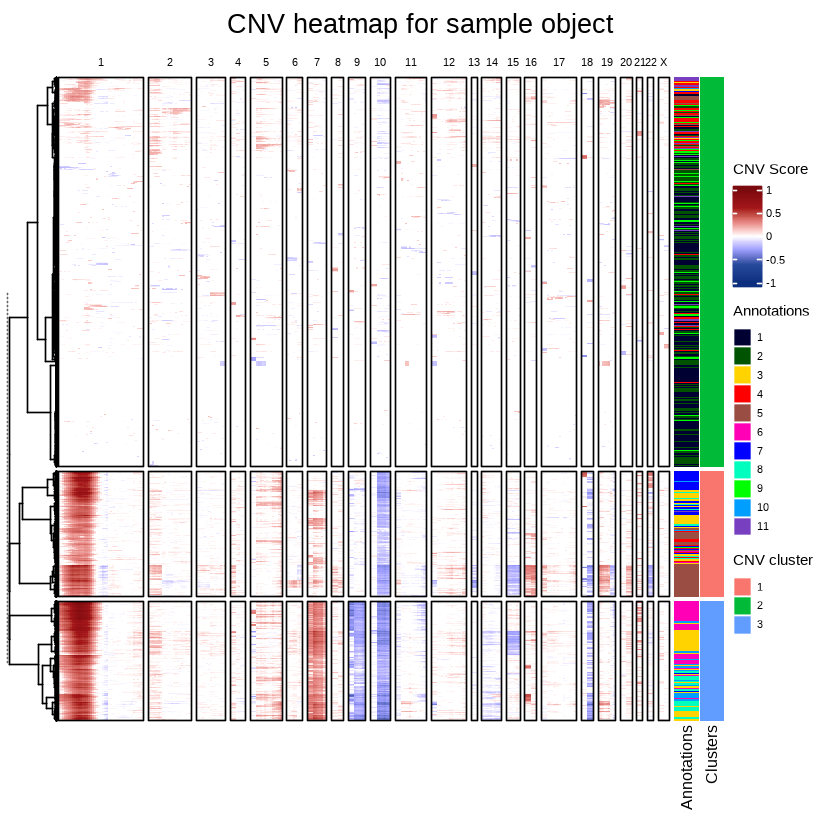

In [13]:
object <- fastCNV(object, 
                    sampleName = "object",
                    referenceVar = "Spatial_snn_res.0.4",
                    referenceLabel = c("1"),
                    k_clusters = 3,
                    outputType = "pdf",
                    printPlot = T)

Saving 6.67 x 6.67 in image


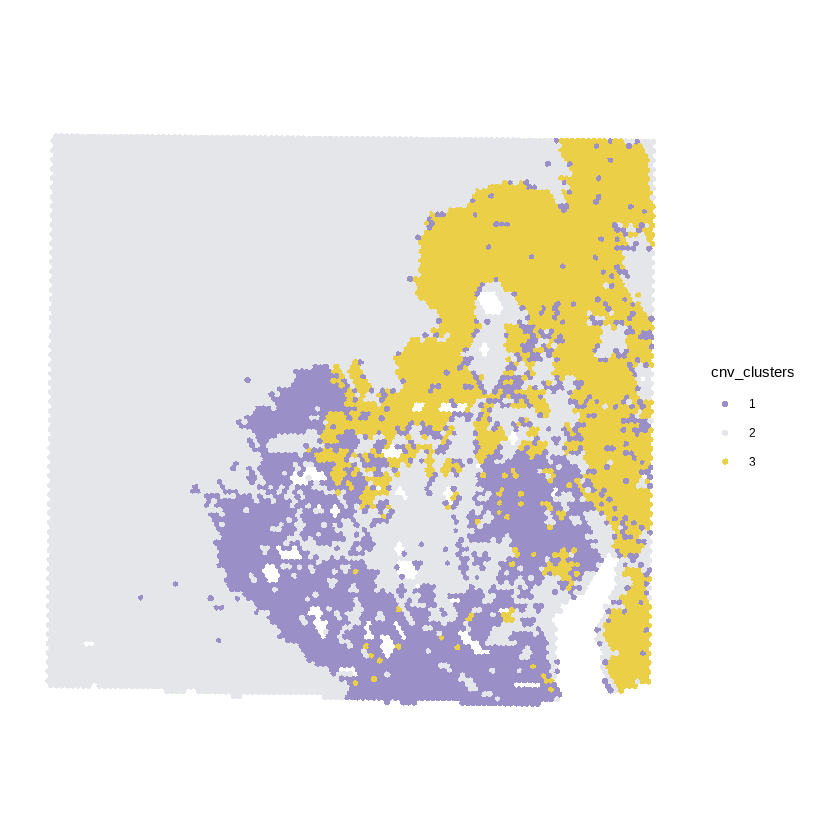

In [37]:
my_colors <- c('1'="#9a90c7",'2'="#e5e6e9",'3'="#ebcf46")  # 注意反引号包裹数字

p <- SpatialDimPlot(
  object,
  group.by = "cnv_clusters",  # 原始列，不用复制为因子
  pt.size.factor = 2.2,
  image.alpha = 0,
  cols = my_colors           # named vector 映射每个分组
)

p
ggsave("./P7-2_cnv_cluster.pdf", p)

Saving 6.67 x 6.67 in image


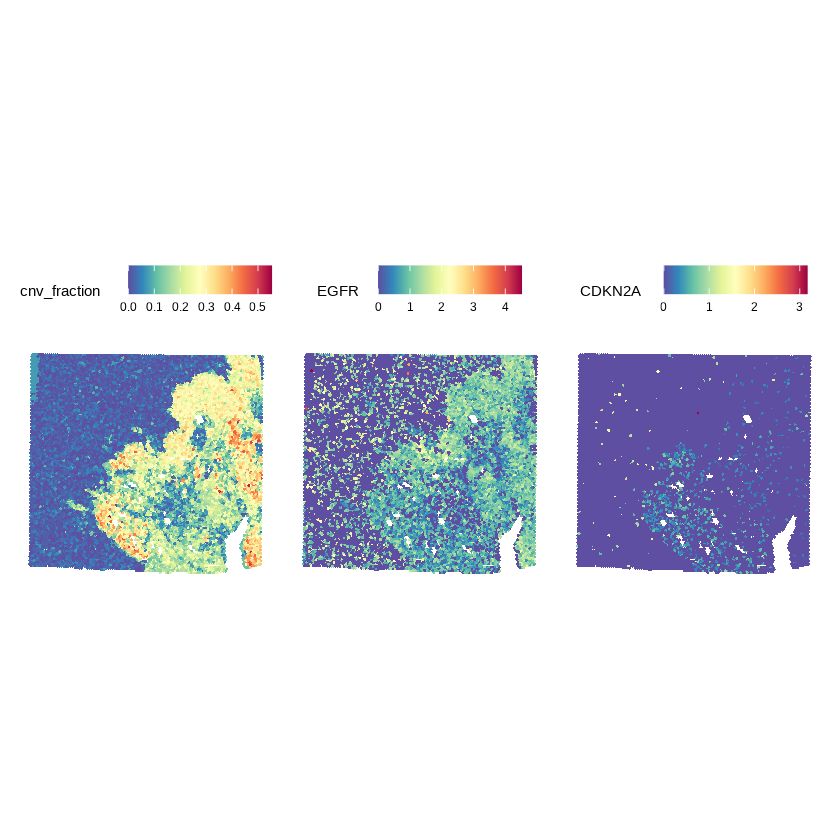

In [54]:
p = SpatialFeaturePlot(
    object, 
    features = c("cnv_fraction","EGFR","CDKN2A"), 
    pt.size.factor = 2.2,
    image.alpha = 0)
p
ggsave("./P7-2_cnv_fraction.pdf", p)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saving 6.67 x 6.67 in image


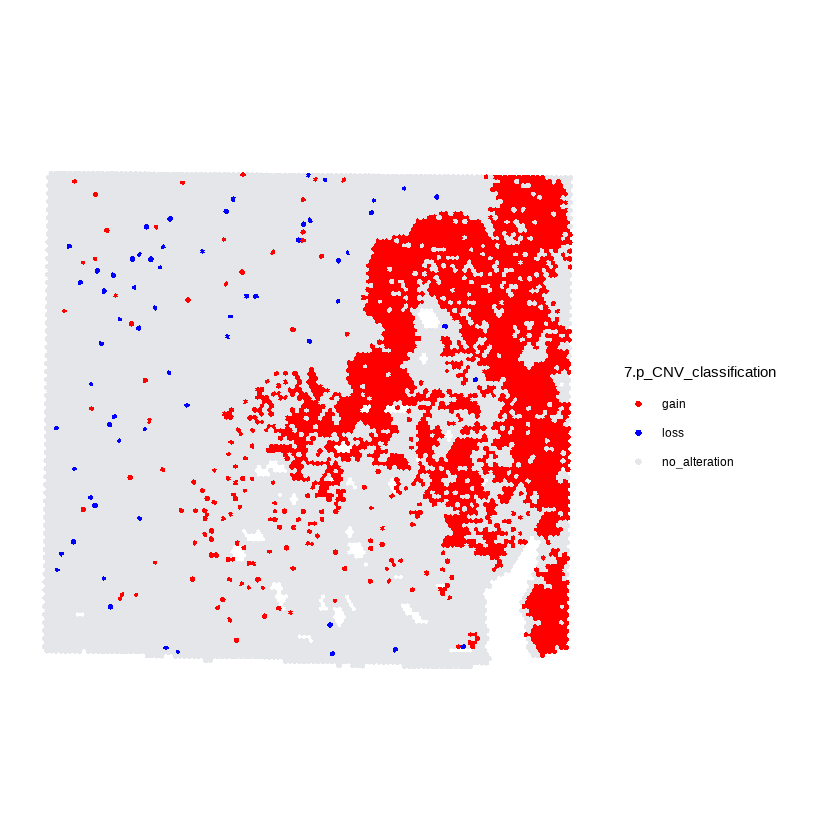

In [56]:
p = SpatialDimPlot(object, 
                   group.by = c("7.p_CNV_classification"),
                   pt.size.factor = 2.2,
                   image.alpha = 0) +
  scale_fill_manual(values = c(gain = "red", no_alteration = "#e5e6e9", loss = "blue"))
p
ggsave(p, file = "P7-2_7p_gain.pdf")

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saving 6.67 x 6.67 in image


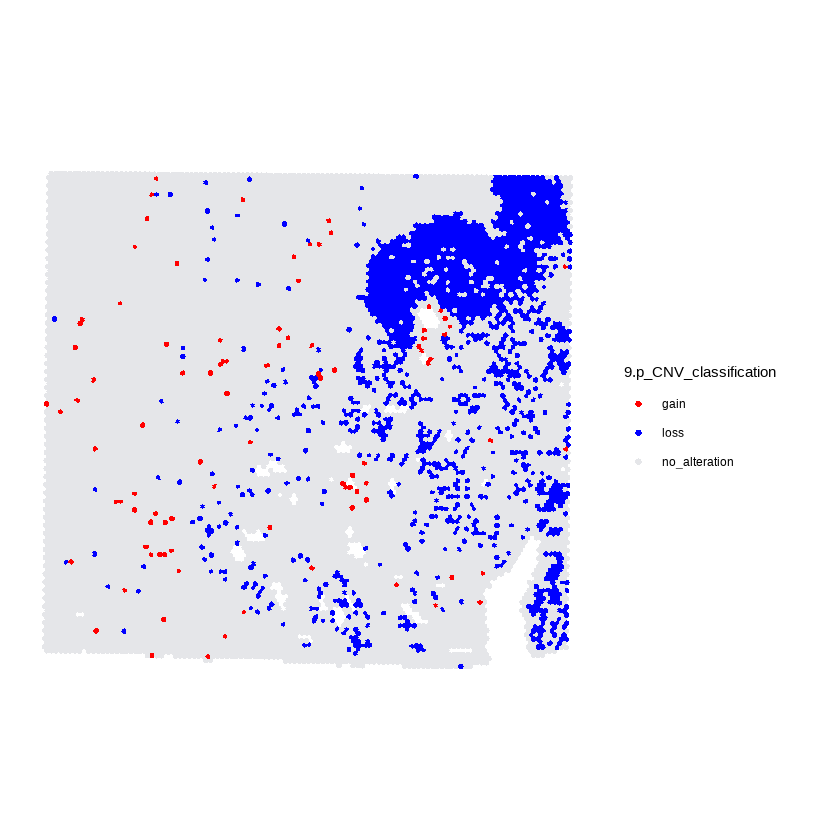

In [40]:
p = SpatialDimPlot(object, 
                   group.by = "9.p_CNV_classification",
                   pt.size.factor = 2.2,
                   image.alpha = 0) +
  scale_fill_manual(values = c(gain = "red", no_alteration = "#e5e6e9", loss = "blue"))
p
ggsave(p, file = "P7-2_9p_loss.pdf")

Warning message in stat_compare_means(method = "wilcox.test", label = "p.format", :
“Ignoring unknown parameters: `p.adjust.method`”


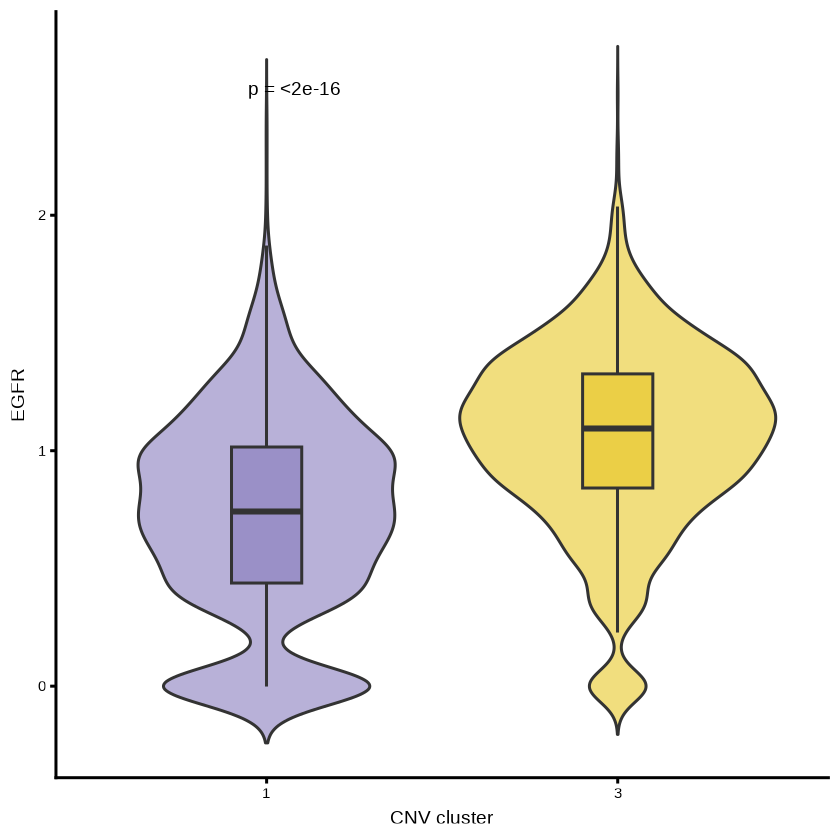

In [51]:
meta_df <- FetchData(object, vars = c("cnv_clusters", "EGFR"))
meta_df$cnv_clusters <- factor(meta_df$cnv_clusters)
meta_df = meta_df[meta_df$cnv_clusters %in% c(1,3),]

p <- ggplot(meta_df, aes(x = cnv_clusters, y = EGFR, fill = cnv_clusters)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  geom_boxplot(width = 0.2, outlier.shape = NA) +
  scale_fill_manual(values = my_colors) +
  stat_compare_means(
    method = "wilcox.test",        
    label = "p.format",    
    p.adjust.method = "BH"
  ) +
  theme_classic(base_size = 14) +
  theme(legend.position = "none") +
  labs(x = "CNV cluster", y = "EGFR")

p
ggsave("./P7-2_EGFR_vln.pdf", p, width = 2, height = 5)

Warning message in stat_compare_means(method = "wilcox.test", label = "p.format", :
“Ignoring unknown parameters: `p.adjust.method`”


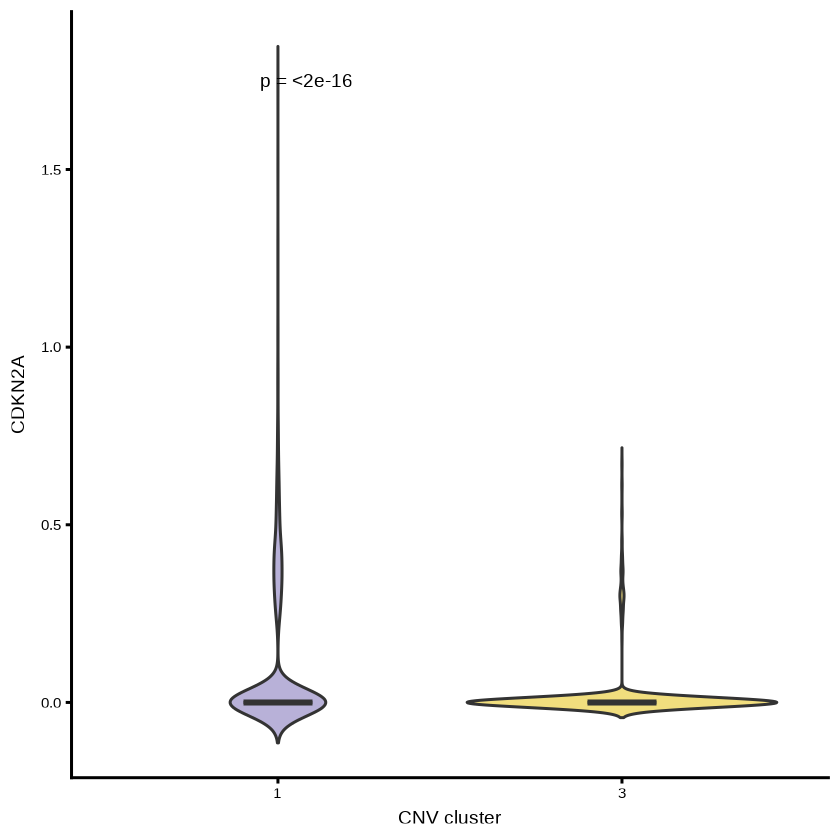

In [53]:
meta_df <- FetchData(object, vars = c("cnv_clusters", "CDKN2A"))
meta_df$cnv_clusters <- factor(meta_df$cnv_clusters)
meta_df = meta_df[meta_df$cnv_clusters %in% c(1,3),]

p <- ggplot(meta_df, aes(x = cnv_clusters, y = CDKN2A, fill = cnv_clusters)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  geom_boxplot(width = 0.2, outlier.shape = NA) +
  scale_fill_manual(values = my_colors) +
  stat_compare_means(
    method = "wilcox.test",        
    label = "p.format",    
    p.adjust.method = "BH"
  ) +
  theme_classic(base_size = 14) +
  theme(legend.position = "none") +
  labs(x = "CNV cluster", y = "CDKN2A")

p
ggsave("./P7-2_CDKN2A_vln.pdf", p, width = 2, height = 5)

## Step3

### Import the prediction scores for each spot generated by DEPICT.

In [11]:
## During DEPICT inference, users can either select specific drugs for prediction or perform inference for all available drugs and subsequently filter the results during downstream analysis.

In [22]:
DEPICT = read.csv("./P7_LUAD2_inference_results.csv", header = T)

In [18]:
drugs <- c("Gefitinib","Erlotinib","Afatinib","Dacomitinib","Osimertinib")

In [23]:
for (drug in drugs) {
  
  DEPICT2 <- DEPICT[DEPICT$Drug_name %in% drug, ]
  rownames(DEPICT2) <- DEPICT2$Samples_id
  
  DEPICT2 <- DEPICT2[, "Score", drop = FALSE]
  DEPICT2[,1] <- as.numeric(DEPICT2[,1])
  colnames(DEPICT2) <- paste0("DEPICT_", drug, "_result")
  
  object <- AddMetaData(object, DEPICT2)
}

In [30]:
# Set the normal cluster (cluster 2) to NA and normalize the DEPICT scores across the remaining tumor regions.

In [29]:
result_cols <- grep("result$", colnames(object@meta.data), value = TRUE)
for (col in result_cols) {
  
  x <- object@meta.data[[col]]
  cluster <- object@meta.data$cnv_clusters
  
  x_new <- x
  x_new[cluster == 2] <- NA   ## normal cluster
  
  idx <- cluster %in% c(1,3)  ## tumor cluster
  
  min.val <- min(x_new[idx], na.rm = TRUE)
  max.val <- max(x_new[idx], na.rm = TRUE)
  
  x_norm <- x_new
  x_norm[idx] <- (x_new[idx] - min.val) / (max.val - min.val)
  
  object@meta.data[[col]] <- x_norm
}

In [ ]:
depict_list <- colnames(object@meta.data)[grep("^DEPICT_", colnames(object@meta.data))]
depict_list

In [33]:
drugs <- c("DEPICT_Gefitinib_result",
           "DEPICT_Erlotinib_result",
           "DEPICT_Afatinib_result",
           "DEPICT_Dacomitinib_result",
           "DEPICT_Osimertinib_result"
          )

Saving 6.67 x 6.67 in image


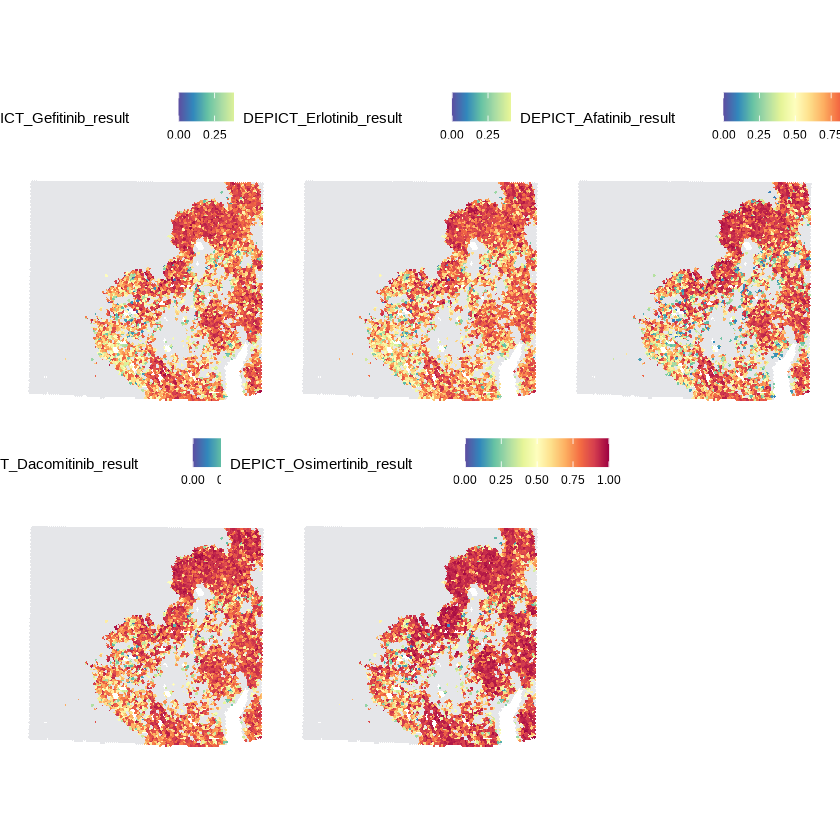

In [34]:
p <- SpatialFeaturePlot(
    object,
    features = drugs,
    pt.size.factor = 2.2,
    image.alpha = 0
  )
for (i in seq_along(p)) {
  sc <- p[[i]]$scales$get_scales("fill")
  sc$na.value <- "#e5e6e9"
}
p
ggsave(p, file = "P7-2_egfr_drug.pdf")

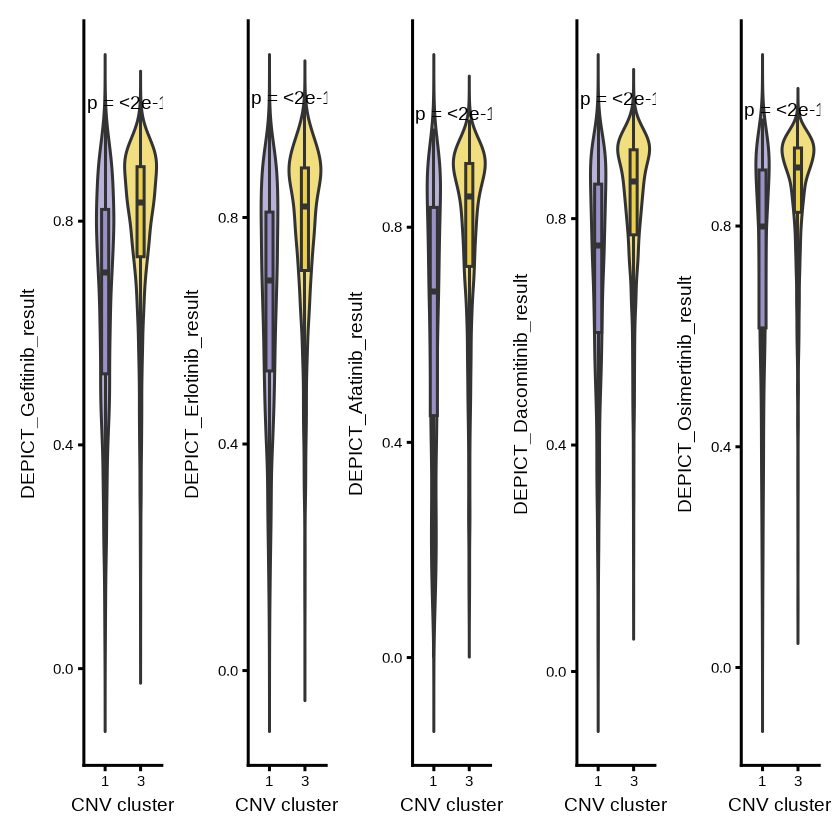

In [45]:
drugs <- c(
  "DEPICT_Gefitinib_result","DEPICT_Erlotinib_result","DEPICT_Afatinib_result",
  "DEPICT_Dacomitinib_result","DEPICT_Osimertinib_result"
)

plots <- list()

for (drug in drugs) {
  meta_df <- FetchData(object, vars = c("cnv_clusters", drug))
  colnames(meta_df)[2] <- "value" 
  meta_df$cnv_clusters <- factor(meta_df$cnv_clusters)
  meta_df <- meta_df[meta_df$cnv_clusters %in% c(1,3),]

  p <- ggplot(meta_df, aes(x = cnv_clusters, y = value, fill = cnv_clusters)) +
    geom_violin(trim = FALSE, alpha = 0.7) +
    geom_boxplot(width = 0.2, outlier.shape = NA) +
    scale_fill_manual(values = my_colors) +
    stat_compare_means(
      method = "wilcox.test",
      label = "p.format"
    ) +
    theme_classic(base_size = 14) +
    theme(legend.position = "none") +
    labs(x = "CNV cluster", y = drug)

  plots[[drug]] <- p
}

final_plot <- wrap_plots(plots, ncol = 5)
final_plot
ggsave("./P7-2_egfr_vln.pdf", final_plot, width = 20, height = 5)

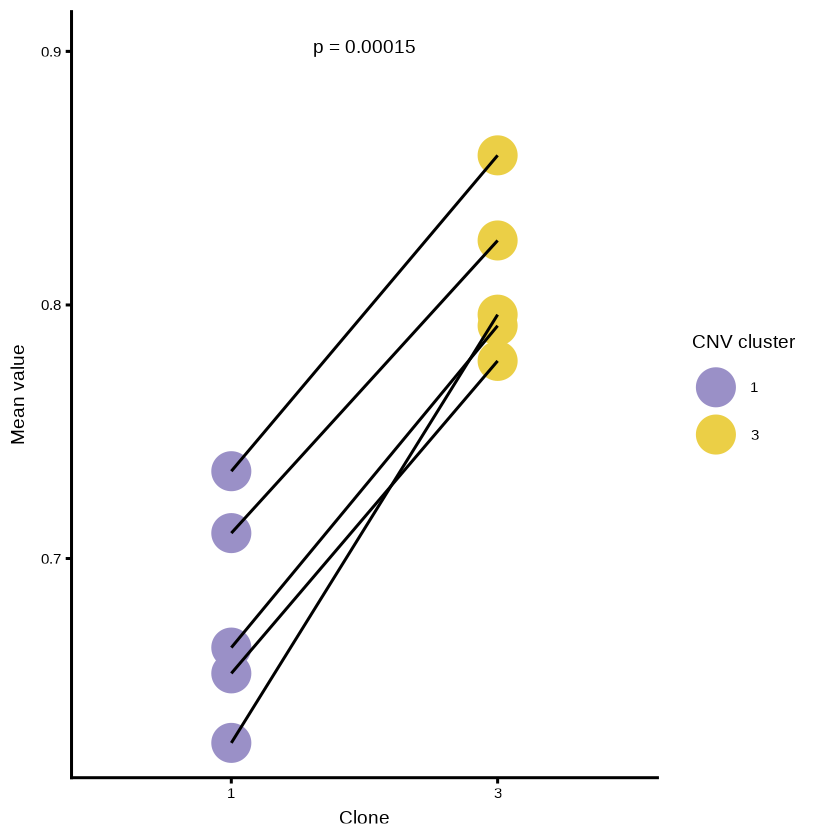

In [48]:
drugs <- c(
  "DEPICT_Gefitinib_result","DEPICT_Erlotinib_result","DEPICT_Afatinib_result",
  "DEPICT_Dacomitinib_result","DEPICT_Osimertinib_result"
)

meta_df <- FetchData(object, vars = c("cnv_clusters", drugs))
meta_df$cnv_clusters <- factor(meta_df$cnv_clusters)
meta_df <- meta_df[meta_df$cnv_clusters %in% c(1,3),]

summary_df <- meta_df %>%
  pivot_longer(cols = all_of(drugs), names_to = "drug", values_to = "value") %>%
  group_by(cnv_clusters, drug) %>%
  summarise(mean_value = mean(value, na.rm = TRUE), .groups = "drop")

paired_df <- summary_df %>%
  pivot_wider(names_from = cnv_clusters, values_from = mean_value) %>%
  rename(Group1 = `1`, Group3 = `3`) %>%
  pivot_longer(cols = c(Group1, Group3), names_to = "cnv_clusters", values_to = "mean_value") %>%
  mutate(cnv_clusters = recode(cnv_clusters, "Group1" = "1", "Group3" = "3"))

stat_test <- t.test(paired_df$mean_value[paired_df$cnv_clusters=="1"],
                         paired_df$mean_value[paired_df$cnv_clusters=="3"],
                         paired = TRUE)

label_df <- data.frame(
  x = 1.5, 
  y = max(paired_df$mean_value) * 1.05, 
  label = sprintf("p = %.5f", stat_test$p.value)
)

p = ggplot(paired_df, aes(x = cnv_clusters, y = mean_value, group = drug)) +
  geom_point(aes(color = cnv_clusters), size = 10) +
  geom_line(aes(group = drug), color = "black") +  
  scale_color_manual(values = my_colors) +
  theme_classic(base_size = 14) +
  labs(x = "Clone", y = "Mean value", color = "CNV cluster") +
  geom_text(data = label_df, aes(x = x, y = y, label = label), inherit.aes = FALSE)
p
ggsave("./P7-2_egfr_pair.pdf", p, width = 6, height = 5)